# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Running best Oracle model on all Image-Datasets [2] \
[7] Running best Oracle model on all Image-Datasets with a different backbone [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [1]:
# Some imports and general information

import mlflow
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
from IPython.display import display

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/perf_dal_2.db
# scp phahn@cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_2.db .

# Command to sync the artifacts
# rsync -ravz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/dal-toolbox/publications/perf_dal/slurm/paul/mlruns/ /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/paul/mlruns/

# Datasets
datasets = {
    'cifar10': {'qs':10, 'n':'CIFAR10'}, 
    'stl10':{'qs':10, 'n':'STL10'}, 
    'snacks':{'qs':20, 'n':'SNACKS'}, 
    'flowers102':{'qs':25, 'n':'Flowers102'}, 
    'dtd':{'qs':50, 'n':'DTD'}, 
    'food101':{'qs':100, 'n':'Food101'}, 
    'cifar100':{'qs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'qs':200, 'n': 'TinyImageNet'},
    'imagenet':{'qs':1000, 'n':'ImageNet'},
    'dopanim':{'qs':25, 'n':'Dopanim'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red', 'ls':'-'},
    'badge':{'n':'BADGE', 'c':'blue', 'ls':'-'},
    'bait':{'n':'BAIT', 'c':'green', 'ls':'-'},
    'coreset':{'n':'CoreSet', 'c':'purple', 'ls':'-'},
    'dropquery':{'n':'DropQuery', 'c':'orange', 'ls':'-'},
    'margin':{'n':'Margin', 'c':'cyan', 'ls':'-'},
    'random':{'n':'Random', 'c':'black', 'ls':'-'},
    'typiclust':{'n':'Typiclust', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(11)':{'n':'Our Approach (11)', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(55)':{'n':'Our Approach (55)', 'c':'red', 'ls':':'},
    'lazy+vary oracle(110)':{'n':'Our Approach (110)', 'c':'red', 'ls':'-.'},
    'lazy+vary oracle(220)':{'n':'Our Approach (220)', 'c':'red', 'ls':':'},

    'naive oracle(11)':{'n':'Naive (11)', 'c':'blue', 'ls':'--'},
    'naive oracle(55)':{'n':'Naive (55)', 'c':'blue', 'ls':':'},
    'naive oracle(110)':{'n':'Naive (110)', 'c':'blue', 'ls':'-.'},
    'naive oracle(220)':{'n':'Naive (220)', 'c':'blue', 'ls':':'},

    'Lazy+Vary Oracle (acq_size = 5)':{'n':'acq_size = 5', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 10)':{'n':'acq_size = 10', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 20)':{'n':'acq_size = 20', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 40)':{'n':'acq_size = 40', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 25)':{'n':'acq_size = 25', 'c':'orange', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 50)':{'n':'acq_size = 50', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 100)':{'n':'acq_size = 100', 'c':'green', 'ls':'--'},
    'Lazy+Vary Oracle (acq_size = 200)':{'n':'acq_size = 200', 'c':'red', 'ls':'--'},

    'Lazy+Vary Oracle (perf_est = cross_entropy)':{'n':'perf_est = cross_entropy', 'c':'red', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = zero_one)':{'n':'perf_est = zero_one', 'c':'blue', 'ls':'--'},
    'Lazy+Vary Oracle (perf_est = brier)':{'n':'perf_est = brier', 'c':'green', 'ls':'--'},

    'lazy+vary oracle(110) cross_entropy 0.01':{'n':'Cross Entropy (0.01)', 'c':'yellow', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.01':{'n':'Zero One (0.01)', 'c':'yellow', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.01':{'n':'Brier (0.01)', 'c':'yellow', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 0.1':{'n':'Cross Entropy (0.1)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 0.1':{'n':'Zero One (0.1)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 0.1':{'n':'Brier (0.1)', 'c':'cyan', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 1':{'n':'Cross Entropy (1)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 1':{'n':'Zero One (1)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 1':{'n':'Brier (1)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 2':{'n':'Cross Entropy (2)', 'c':'purple', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 2':{'n':'Zero One (2)', 'c':'purple', 'ls':'-'},
    'lazy+vary oracle(110) brier 2':{'n':'Brier (2)', 'c':'purple', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 5':{'n':'Cross Entropy (5)', 'c':'brown', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 5':{'n':'Zero One (5)', 'c':'brown', 'ls':'-'},
    'lazy+vary oracle(110) brier 5':{'n':'Brier (5)', 'c':'brown', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 10':{'n':'Cross Entropy (10)', 'c':'green', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 10':{'n':'Zero One (10)', 'c':'green', 'ls':'-'},
    'lazy+vary oracle(110) brier 10':{'n':'Brier (10)', 'c':'green', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 20':{'n':'Cross Entropy (20)', 'c':'blue', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 20':{'n':'Zero One (20)', 'c':'blue', 'ls':'-'},
    'lazy+vary oracle(110) brier 20':{'n':'Brier (20)', 'c':'blue', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 25':{'n':'Cross Entropy (25)', 'c':'pink', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 25':{'n':'Zero One (25)', 'c':'pink', 'ls':'-'},
    'lazy+vary oracle(110) brier 25':{'n':'Brier (25)', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 30':{'n':'Cross Entropy (30)', 'c':'orange', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 30':{'n':'Zero One (30)', 'c':'orange', 'ls':'-'},
    'lazy+vary oracle(110) brier 30':{'n':'Brier (30)', 'c':'orange', 'ls':'--'},
    'lazy+vary oracle(110) cross_entropy 50':{'n':'Cross Entropy (50)', 'c':'cyan', 'ls':'-.'},
    'lazy+vary oracle(110) zero_one 50':{'n':'Zero One (50)', 'c':'cyan', 'ls':'-'},
    'lazy+vary oracle(110) brier 50':{'n':'Brier (50)', 'c':'cyan', 'ls':'--'},

    'Oracle':{'n':'Oracle', 'c':'black', 'ls':'-.'},

    'Oracle (-0)':{'n':'Oracle (full)', 'c':'orange', 'ls':'-'},
    'Oracle (-1)':{'n':'Oracle (-1)', 'c':'green', 'ls':'-'},
    'Oracle (-2)':{'n':'Oracle (-2)', 'c':'brown', 'ls':'-'},
    'Oracle (-2) Inc':{'n':'Oracle (-2) Inc', 'c':'brown', 'ls':'-.'},
    'Oracle (-3)':{'n':'Oracle (-3)', 'c':'blue', 'ls':'-'},
    'Oracle (-4)':{'n':'Oracle (-4)', 'c':'red', 'ls':'-'},
    'Oracle (-5)':{'n':'Oracle (-5)', 'c':'pink', 'ls':'-'},
    'Oracle (-6)':{'n':'Oracle (-6)', 'c':'cyan', 'ls':'-'},
    'Oracle (-7)':{'n':'Oracle (-7)', 'c':'yellow', 'ls':'-'},
    'Oracle (-8)':{'n':'Oracle (-8)', 'c':'purple', 'ls':'-'},
    'Oracle (-9)':{'n':'Oracle (-9)', 'c':'grey', 'ls':'-'},
    'Oracle (-10)':{'n':'Oracle (-10)', 'c':'silver', 'ls':'-'},

    'Oracle (25/220)':{'n':'Oracle (25/220)', 'c':'blue', 'ls':'-'},
    'Oracle (37/160)':{'n':'Oracle (37/160)', 'c':'red', 'ls':'-'},
    'Oracle (75/82)':{'n':'Oracle (75/82)', 'c':'green', 'ls':'-'},
    'Oracle (100/55)':{'n':'Oracle (100/55)', 'c':'pink', 'ls':'-'},

    'lazy+vary oracle(5 epochs)':{'n':'5 Epochs', 'c':'red', 'ls':'--'},
    'lazy+vary oracle(10 epochs)':{'n':'10 Epochs', 'c':'blue', 'ls':'--'},
    'lazy+vary oracle(25 epochs)':{'n':'25 Epochs', 'c':'green', 'ls':'--'},
    'lazy+vary oracle(50 epochs)':{'n':'50 Epochs', 'c':'yellow', 'ls':'--'},
    'lazy+vary oracle(75 epochs)':{'n':'75 Epochs', 'c':'cyan', 'ls':'--'},
    'lazy+vary oracle(100 epochs)':{'n':'100 Epochs', 'c':'pink', 'ls':'--'},
    'lazy+vary oracle(150 epochs)':{'n':'150 Epochs', 'c':'orange', 'ls':'--'},
    'lazy+vary oracle(200 epochs)':{'n':'200 Epochs', 'c':'black', 'ls':'-'},
}

sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal_2.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

def style_negative(v, props=''):
    return props if v.count('-') > 1 else None

def df_style(val):
    return "font-weight: bold"

In [ ]:
# Plotting functions for a pairwise comparison in one dset, averaged over all dsets and a global comparison
def plot_learning_curves(all_acc_curves_strategies, strats, dsets, query_strategies, datasets, baseline="random", nrows=1, ncols=2, figsize=(10,4), only_tables=False, legend_dist=1.225):
    if not only_tables:
        fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, tight_layout=True)
    auc_values_rel = {}
    final_acc_rel = {}
    auc_values_abs = {}
    final_acc_abs = {}
    for i, dset in enumerate(dsets):
        auc_values_rel[dset] = {}
        final_acc_rel[dset] = {}
        auc_values_abs[dset] = {}
        final_acc_abs[dset] = {}

        rand_accs = list(all_acc_curves_strategies[dset][baseline].values()) 
        avg_rand_accs = np.mean(rand_accs, axis=0)
        rand_auc = np.mean(rand_accs, axis=1)
        rand_final_accs = [ac[-1]*100 for ac in rand_accs]
        rand_auc_mean, rand_auc_std = np.mean(rand_auc), np.std(rand_auc)
        rand_acc_mean, rand_acc_std = np.mean(rand_final_accs), np.std(rand_final_accs)
        auc_values_rel[dset][baseline] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
        final_acc_rel[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        auc_values_abs[dset][baseline] = str(rand_auc_mean.round(3)) + '+/-' + str(rand_auc_std.round(3))
        final_acc_abs[dset][baseline] = str(rand_acc_mean.round(2)) + '+/-' + str(rand_acc_std.round(2))
        if not only_tables:
            if nrows == 1:
                plt.axes(ax[i])
            else:
                plt.axes(ax[i%nrows][i//nrows])
            
        n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(21)]
        for qs in all_acc_curves_strategies[dset]:
            if qs in strats:
                accs = list(all_acc_curves_strategies[dset][qs].values())
                avg_accs = np.mean(accs, axis=0)
                final_accs = [ac[-1]*100 for ac in accs]
                aucs = np.mean(accs, axis=1)
                aucs_mean, aucs_std  = np.mean(aucs), np.std(aucs)
                final_acc_mean, final_acc_std = np.mean(final_accs), np.std(final_accs)

                if qs != baseline:
                    auc_values_rel[dset][qs] = str((aucs_mean - rand_auc_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                    final_acc_rel[dset][qs] = str((final_acc_mean - rand_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                    auc_values_abs[dset][qs] = str((aucs_mean).round(3)) + '+/-' + str(aucs_std.round(3))
                    final_acc_abs[dset][qs] = str((final_acc_mean).round(2)) + '+/-' + str(final_acc_std.round(2))
                if not only_tables:
                    plt.plot(n_labeled_samples, avg_accs - avg_rand_accs, c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
        if not only_tables:
            plt.xlabel('Labeled Samples')
            if i//nrows == 0:
                plt.ylabel('Relative Test Accuracy \n Improvement (%)')
            plt.grid(True)
            plt.title(datasets[dset]['n'])
            plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
    if not only_tables:
        handles, labels = plt.gca().get_legend_handles_labels()
        fig.legend(loc="right", bbox_to_anchor=[legend_dist, .5], handles=handles, labels=labels)
        plt.show()
    return {
        'acc_rel':final_acc_rel,
        'acc_abs':final_acc_abs,
        'auc_rel':auc_values_rel,
        'auc_abs':auc_values_abs
    }

def plot_global_pairwise_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=strategies, columns=strategies)
    for strat1 in strategies:
        for strat2 in strategies:
            if strat1 == strat2:
                win_rates.loc[strat1, strat2] = 0.0
            else:
                accs1, accs2 = [], []
                for dset in dsets:
                    for key in results[dset][strat1]:
                        accs1.append(results[dset][strat1][key])
                        accs2.append(results[dset][strat2][key])
                means1 = np.mean(accs1, axis=1)
                means2 = np.mean(accs2, axis=1)

                assert means1.shape == means2.shape, f'On {dset}, {strat1} and {strat2} do not have the same number of results'
                
                comparisons = means1.round(4) > means2.round(4)
                wins = np.sum(comparisons) / means1.shape[0]
                win_rates.loc[strat1, strat2] = wins
    win_rates.index = [strat.capitalize() for strat in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)
    plt.figure(figsize=figsize)
    sns.heatmap(win_rates.astype(float).T, annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels, yticklabels=Labels)
    plt.title(f"Global Pairwise Comparison")
    plt.ylabel("Challenged Strategy")
    plt.xlabel("Challenging Strategy")
    plt.tight_layout()
    plt.show() 


def plot_global_comparison(results, dsets, strategies, Labels, figsize=(6,5)):
    # Compute win rates
    win_rates = pd.DataFrame(index=dsets, columns=strategies)
    for dset in dsets:
        for strat1 in strategies:
            accs1 = []
            for key in results[dset][strat1]:
                accs1.append(results[dset][strat1][key])
            means1 = np.mean(accs1, axis=1)
            comparisons = []
            for strat2 in strategies:
                if strat2 != strat1:
                    accs2 = []
                    for key in results[dset][strat1]:
                        accs2.append(results[dset][strat2][key])
                    means2 = np.mean(accs2, axis=1)
                    comparison = means1.round(4) > means2.round(4)
                    comparisons.append(comparison)
            comp = np.prod(comparisons, axis=0)
            wins = np.sum(comp) / means1.shape[0]
            win_rates.loc[dset, strat1] = wins

    win_rates.index = [dset.capitalize() for dset in win_rates.index]
    win_rates.columns = [strat.capitalize() for strat in win_rates.columns]

    # Plot the heatmap
    #win_rates = win_rates.sort_index(axis=0)
    #win_rates = win_rates.sort_index(axis=1)

    plt.figure(figsize=figsize)
    plt.title(f"Highest AUC per Dataset (%)")
    sns.heatmap(win_rates.astype(float), annot=True, fmt=".2f", cmap="coolwarm", center=.50, xticklabels=Labels)
    plt.ylabel("Dataset")
    plt.xlabel("Strategy")
    plt.tight_layout()
    plt.show()



def plot_average_pick_choices(all_pick_choices, fig_strats, fig_dsets, sampling_strategies, figsize=(12, 5), cmap = 'viridis', n_queries = 20):
    n_plots = len(fig_dsets) * len(fig_strats)

    fig, ax = plt.subplots(nrows=1, ncols=n_plots + 1, figsize=figsize, width_ratios=[1 for _ in range(n_plots)]+ [.2])
    fig.suptitle("Average Pick Choice")
    imshows = []

    for b, strat in enumerate(fig_strats):
        for a, dset in enumerate(fig_dsets):        
            j = a * len(fig_strats) + b
            vmin, vmax = 1, 0
            
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(1, 11):
                    seed = str(seed)
                    im = []
                    for i in range(1,n_queries):
                        if sampl_strat in all_pick_choices[dset][strat][seed]:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        else:
                            im.append(0)
                    img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            vmin, vmax = min(vmin, min(img_avg)), max(vmax, max(img_avg))

            c1 = ax[j].imshow(img_avg, vmin=vmin, vmax=vmax, cmap=cmap)
            imshows.append(c1)

            for (i, k), val in np.ndenumerate(img_avg):
                ax[j].text(k, i, f"{val:.2f}" if f"{val:.2f}" != "0.00" else "X", ha='center', va='center', color='white')
            ax[j].set_xticks(ticks=[0], labels=[strat], rotation=25)

            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            j += 1

    for im in imshows:
        im.set_clim(vmin=vmin, vmax=vmax)

    fig.colorbar(im, cax=ax[-1])
    plt.show()

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [9]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 10 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 808 experiments for experiment_1 with expected 800 experiments.
Issue with coreset dopanim Seed_10


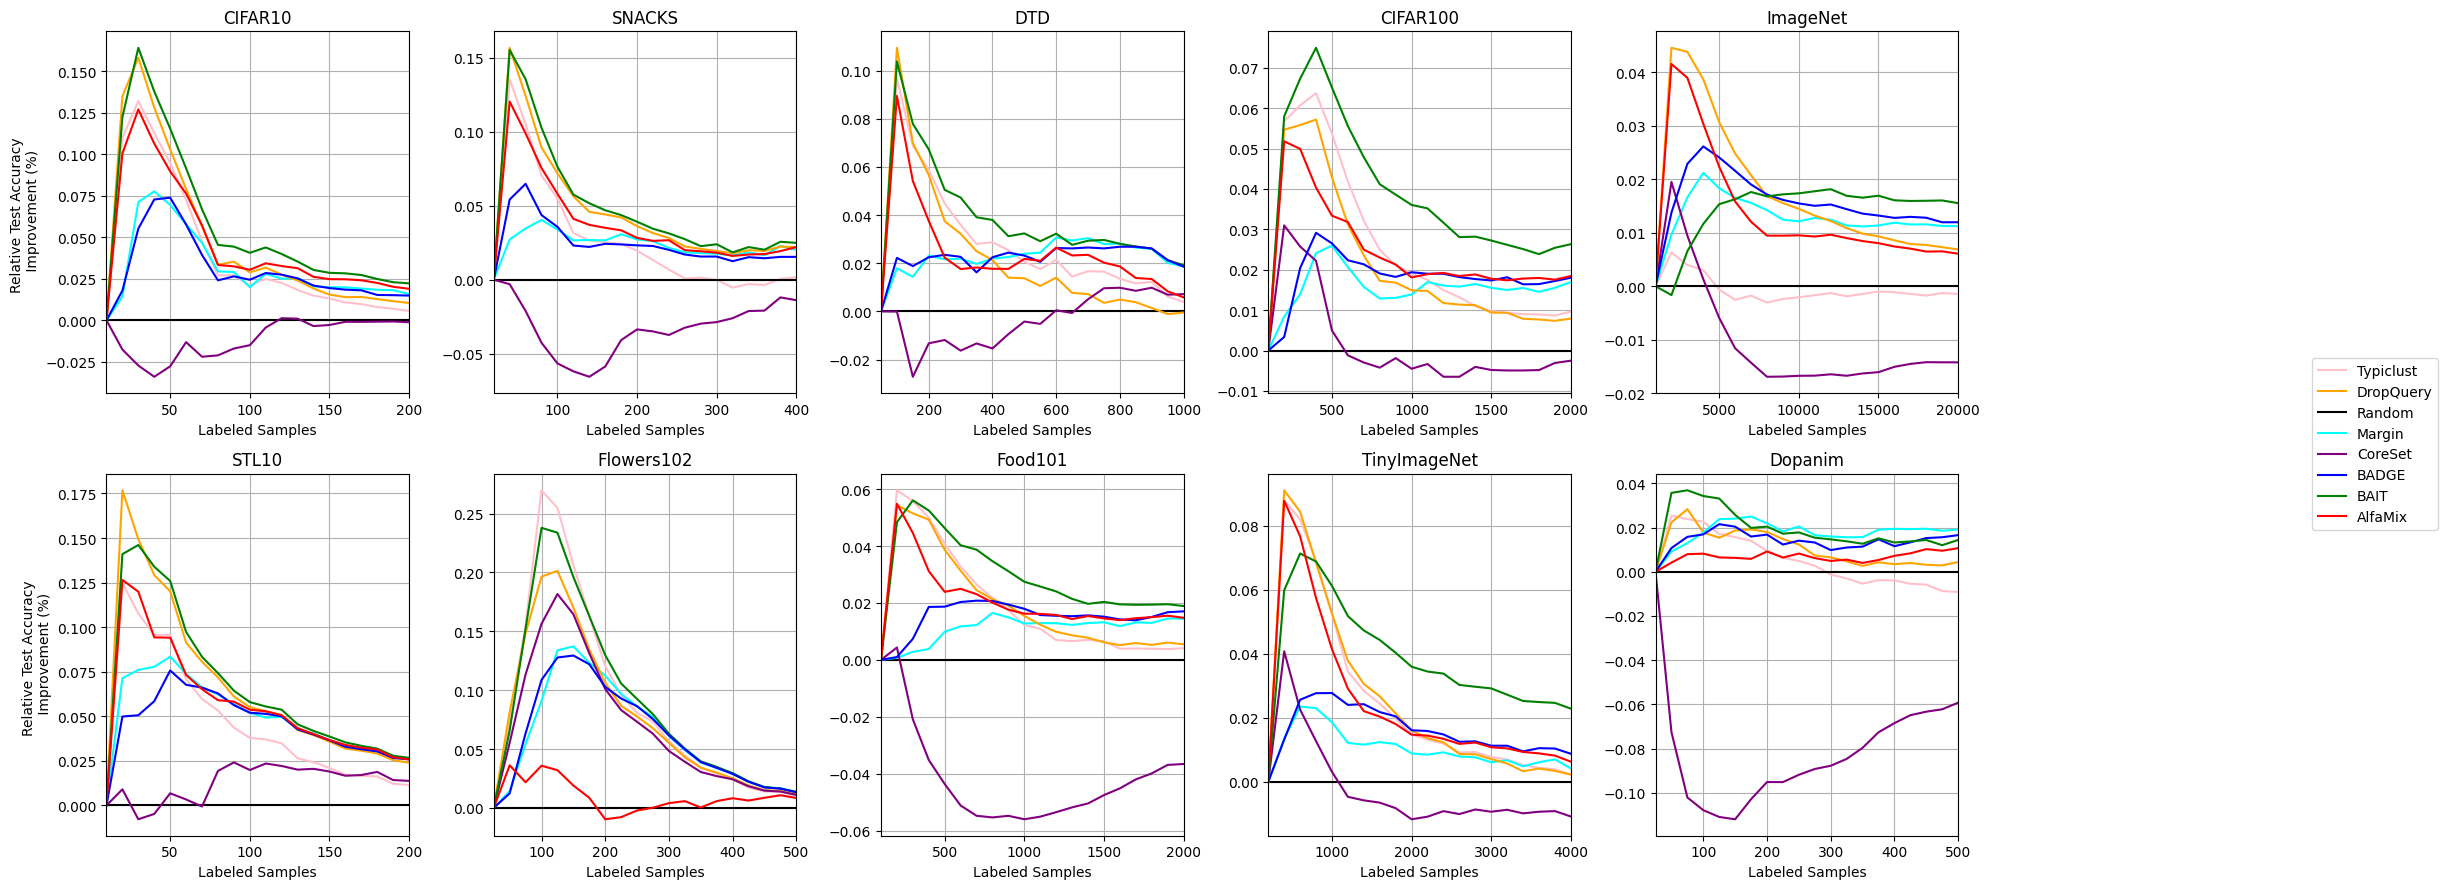

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,92.46+/-0.76,96.43+/-0.84,89.81+/-0.89,98.19+/-0.73,75.02+/-0.54,77.65+/-0.31,76.48+/-0.37,72.94+/-0.26,70.37+/-0.14,78.06+/-0.53
typiclust,0.55+/-0.3,1.06+/-0.29,-0.39+/-0.75,0.84+/-0.18,0.22+/-0.8,0.36+/-0.3,0.79+/-0.32,0.19+/-0.39,-0.11+/-0.18,-0.81+/-0.39
margin,1.65+/-0.2,2.5+/-0.1,1.52+/-0.38,1.11+/-0.11,1.61+/-0.77,1.49+/-0.46,1.65+/-0.4,0.47+/-0.32,1.18+/-0.12,2.04+/-0.65
dropquery,1.06+/-0.33,2.26+/-0.09,1.92+/-0.6,0.98+/-0.14,-0.18+/-0.42,0.46+/-0.33,0.79+/-0.26,0.16+/-0.2,0.67+/-0.23,0.37+/-0.64
coreset,0.12+/-0.5,1.39+/-0.32,-1.26+/-0.79,0.9+/-0.11,0.46+/-0.59,-3.64+/-0.64,-0.31+/-0.55,-0.9+/-0.23,-1.31+/-0.2,-5.84+/-0.84
bait,2.22+/-0.18,2.54+/-0.08,2.04+/-0.38,1.11+/-0.1,1.75+/-0.51,1.78+/-0.26,2.54+/-0.34,2.21+/-0.37,1.55+/-0.13,1.63+/-0.31
badge,1.45+/-0.27,2.48+/-0.1,1.39+/-0.61,1.1+/-0.08,1.63+/-0.51,1.61+/-0.43,1.74+/-0.27,0.94+/-0.25,1.26+/-0.16,1.47+/-0.33
alfamix,1.88+/-0.37,2.46+/-0.07,1.7+/-0.59,0.67+/-0.17,0.34+/-0.72,1.45+/-0.28,1.89+/-0.39,0.62+/-0.32,0.63+/-0.2,1.2+/-0.52


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,stl10,snacks,flowers102,dtd,food101,cifar100,tiny_imagenet,imagenet,dopanim
random,0.833+/-0.016,0.882+/-0.011,0.827+/-0.01,0.812+/-0.014,0.658+/-0.007,0.675+/-0.005,0.667+/-0.005,0.63+/-0.003,0.619+/-0.002,0.711+/-0.008
typiclust,0.037+/-0.006,0.044+/-0.005,0.024+/-0.008,0.083+/-0.006,0.026+/-0.004,0.018+/-0.005,0.024+/-0.004,0.023+/-0.004,-0.001+/-0.002,0.004+/-0.006
margin,0.031+/-0.011,0.048+/-0.003,0.023+/-0.008,0.058+/-0.008,0.022+/-0.005,0.011+/-0.007,0.015+/-0.004,0.01+/-0.002,0.013+/-0.002,0.018+/-0.003
dropquery,0.045+/-0.006,0.063+/-0.004,0.043+/-0.005,0.073+/-0.004,0.02+/-0.004,0.018+/-0.003,0.02+/-0.002,0.024+/-0.002,0.017+/-0.002,0.01+/-0.004
coreset,-0.01+/-0.017,0.013+/-0.011,-0.031+/-0.016,0.065+/-0.008,-0.003+/-0.005,-0.041+/-0.007,0.001+/-0.005,-0.003+/-0.004,-0.01+/-0.002,-0.08+/-0.011
bait,0.055+/-0.009,0.064+/-0.003,0.047+/-0.006,0.084+/-0.005,0.037+/-0.006,0.029+/-0.005,0.037+/-0.003,0.037+/-0.003,0.014+/-0.001,0.019+/-0.006
badge,0.029+/-0.008,0.044+/-0.006,0.023+/-0.005,0.058+/-0.01,0.022+/-0.008,0.015+/-0.006,0.018+/-0.004,0.016+/-0.002,0.015+/-0.002,0.014+/-0.005
alfamix,0.044+/-0.013,0.054+/-0.015,0.036+/-0.006,0.009+/-0.019,0.023+/-0.006,0.02+/-0.005,0.024+/-0.002,0.023+/-0.004,0.013+/-0.002,0.007+/-0.005


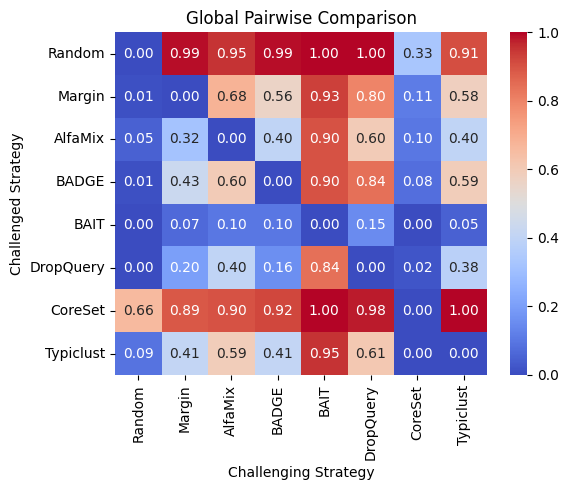

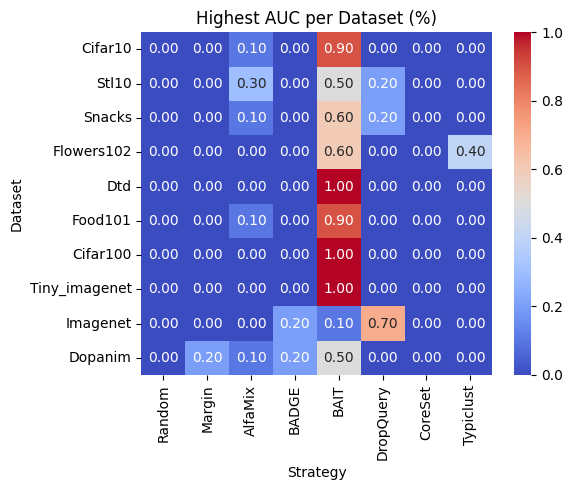

In [10]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9))
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, Labels=Labels)

## Experiment 2 - Oracle Baselines

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [11]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_query_strategies * num_batches

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = ('lazy' if 'typiclust' in run.data.params['al.optimal.strategies'] else 'naive') + ('+vary ' if run.data.params['al.optimal.vary_strat_subset_size'] == 'True' else ' ') + 'oracle' + '('+ run.data.params['al.optimal.num_batches'] +')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_2 #####################################
Found 220 experiments for experiment_2 with expected 180 experiments.


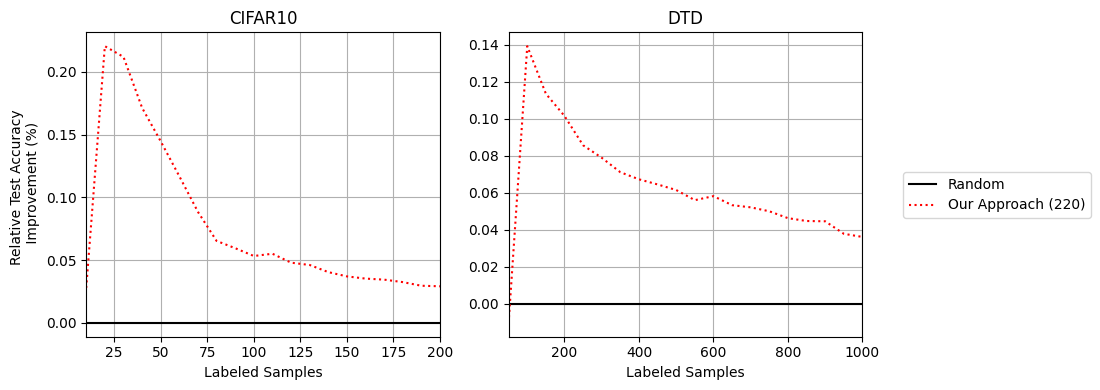

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
random,92.46+/-0.76,75.02+/-0.54
lazy+vary oracle(220),2.88+/-0.19,3.28+/-0.36


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
random,0.833+/-0.016,0.658+/-0.007
lazy+vary oracle(220),0.908+/-0.004,0.719+/-0.004


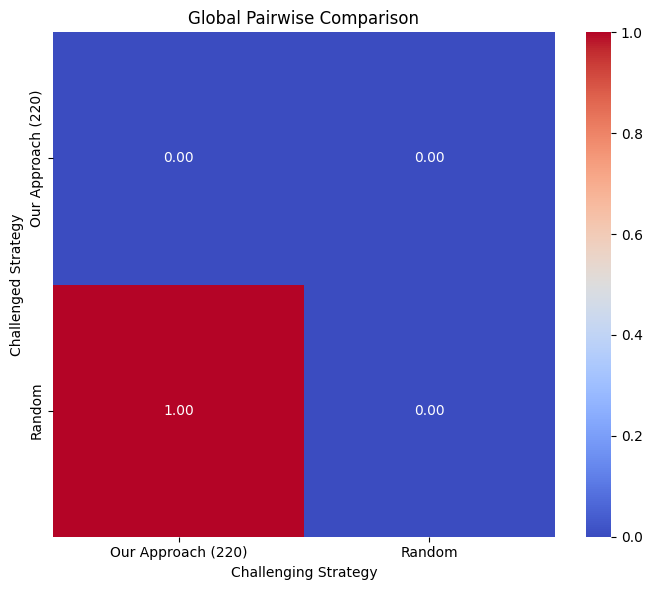

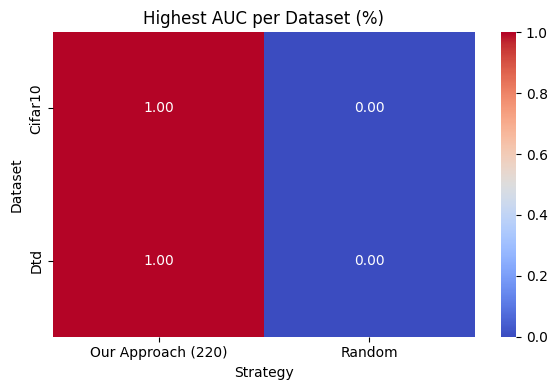

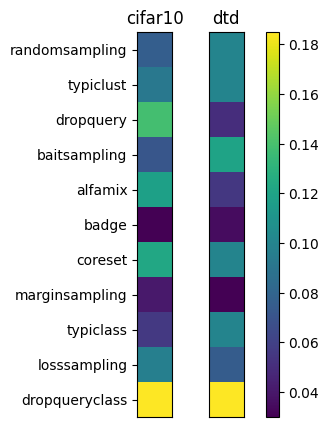

In [14]:
strategies = ['lazy+vary oracle(220)','random']
Labels = ['Our Approach (220)', 'Random']
dsets = ['cifar10', 'dtd']
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'badge', 'coreset', 'marginsampling', 'typiclass', 'losssampling', 'dropqueryclass']

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4))
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_abs)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

fig_strats = ['lazy+vary oracle(110)'] #['lazy oracle(11)', 'lazy+vary oracle(11)', 'lazy oracle(55)', 'lazy+vary oracle(55)', 'lazy oracle(110)', 'lazy+vary oracle(110)']
fig_labels = ['Our Approach (110)'] #['Static (11)', 'Vary(11)', 'Static (55)', 'Vary (55)', 'Static (110)', 'Vary (110)']
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(2,5), plot_xlabels=False, title=None)

## Experiment 3 - How does the query size impact the oracle?

This experiment demonstrates the change in performance when increasing the acq_size while keeping the total number of acquisitions over the experiment constant. 

We only use the strategy lazy+vary oracle(110) as it is the strongest performer.

Num_Acqs = [10, 20, 40]

Datasets = [CIFAR10, STL10]

In [15]:
experiment_name = 'experiment_3'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 3 * 10 * 3 + 2 * 10 * 1)) # n_dsets * n_seeds * n_acq_sizes

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = f'Lazy+Vary Oracle (acq_size = '+run.data.params['al.acq_size']+')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_3 #####################################
Found 111 experiments for experiment_3 with expected 110 experiments.
Issue with Lazy+Vary Oracle (acq_size = 5) cifar10 Seed_7


cifar10 - Lazy+Vary Oracle (acq_size = 5) : 0.852 +/- 0.017
cifar10 - Lazy+Vary Oracle (acq_size = 10) : 0.851 +/- 0.017
cifar10 - Lazy+Vary Oracle (acq_size = 20) : 0.848 +/- 0.017
cifar10 - Lazy+Vary Oracle (acq_size = 40) : 0.849 +/- 0.01
dtd - Lazy+Vary Oracle (acq_size = 25) : 0.649 +/- 0.001
dtd - Lazy+Vary Oracle (acq_size = 50) : 0.648 +/- 0.002
dtd - Lazy+Vary Oracle (acq_size = 100) : 0.638 +/- 0.003
dtd - Lazy+Vary Oracle (acq_size = 200) : 0.632 +/- 0.004


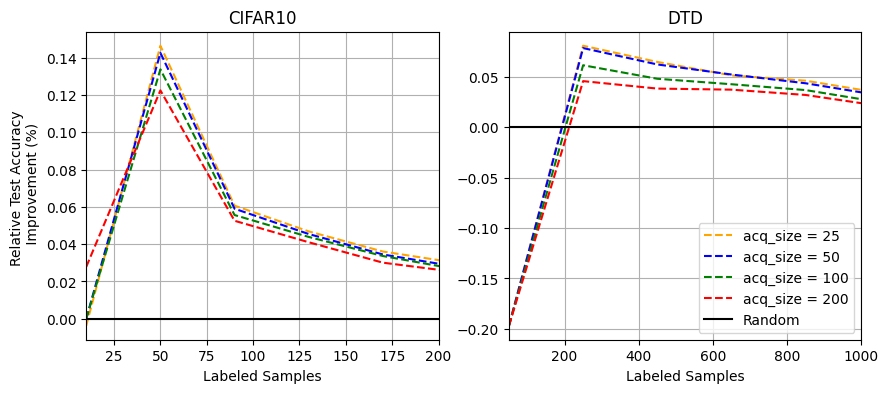

In [37]:
dsets = ['cifar10', 'dtd']

new_accs = {}

for dset in dsets:
    new_accs[dset] = {}
    for i, acq_size in enumerate(['5', '10', '20', '40'] if dset == 'cifar10' else ['25', '50', '100', '200']):
        step_size = [8, 4, 2, 1][i]
        strat = f'Lazy+Vary Oracle (acq_size = {acq_size})'
        accs_reduced = [[accs[j] for j in range(len(accs)) if j % step_size == 0] for accs in list(all_acc_curves_strategies[dset][strat].values())]
        auc_mean = np.mean(accs_reduced)
        auc_std = np.std(np.mean(accs_reduced, axis=1))
        print(dset, "-", strat,":", auc_mean.round(3),"+/-", auc_std.round(3))
        new_accs[dset][strat] = accs_reduced
    rand_accs_reduced = [[accs[j] for j in range(len(accs)) if j % 4 == 0] for accs in list(all_acc_curves_strategies[dset]["random"].values())]
    new_accs[dset]["random"] = rand_accs_reduced

plt.figure(figsize=(10, 4))
for dset in dsets:
    if dset == 'cifar10':
        plt.subplot(1, 2, 1)
    else:
        plt.subplot(1, 2, 2)
    
    n_labeled_samples = [j*datasets[dset]['qs'] + datasets[dset]['qs'] for j in range(0,21,4)]
    for qs in new_accs[dset]:
        plt.plot(n_labeled_samples, np.mean(new_accs[dset][qs], axis=0) - np.mean(new_accs[dset]["random"], axis=0), c=query_strategies[qs]['c'], label=query_strategies[qs]['n'], linestyle=query_strategies[qs]['ls'])
    plt.xlabel('Labeled Samples')
    if dset == 'cifar10':
        plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['qs'], 20*datasets[dset]['qs'])
plt.legend()
plt.show()

## Experiment 4 - How does the performance estimation impact the oracle?

In this experiment, we investigate the influence of the performance metric used for evaluating the different batches.

Perf_Est = [Cross Entropy, 0/1 Loss, Brier Score]

In [ ]:
experiment_name = 'experiment_4'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3)) # n_dsets * n_seeds * n_loss_fn

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = f'Lazy+Vary Oracle (perf_est = '+run.data.params['al.optimal.loss']+')'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
strategies = [qs for qs in query_strategies if 'perf_est' in qs] + ['random']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'dtd']

res_dic = plot_learning_curves(strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, all_acc_curves_strategies=all_acc_curves_strategies, nrows=1, ncols=2, figsize=(9, 4))
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_abs)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_abs)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,5), Labels=Labels)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(5,4), Labels=Labels)

fig_strats = strategies
fig_strats.remove('random')
fig_labels = [query_strategies[strat]['n'] for strat in fig_strats]
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(8, 5))

## Experiment 5 - How does the retraining process impact the oracle?

This experiment investigates wether using bayesian updates instead of retraining the model from scratch can serve as a good performance estimator, making the oracle more efficient.

In [ ]:
experiment_name = 'experiment_5'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 10 * 3)) # n_dsets * n_seeds * n_gammas * n_loss_fn

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        loss_fn = run.data.params['al.optimal.loss']
        update_gamma = run.data.params['al.optimal.update_gamma']
        key = f'lazy+vary oracle(110) ' + loss_fn + ' ' + update_gamma
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
strategies = [qs for qs in query_strategies if 'zero_one ' in qs] + ['lazy+vary oracle(110)']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'dtd']
baseline = "lazy+vary oracle(110)"

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(9, 4), baseline=baseline)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print(f'##################################### Final Test-Accuracies (Relative to {baseline}) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print(f'##################################### Test-AUCs (Relative to {baseline}) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,4), Labels=Labels)

fig_strats = strategies
fig_labels = [query_strategies[strat]['n'] for strat in fig_strats]
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(18, 5))

In [ ]:
qts = {}

for dset in ['cifar10', 'dtd']:
    qts[dset] = {}
    for strat in ['lazy+vary oracle(110)', 'lazy+vary oracle(110) zero_one 10']:
        qts[dset][strat] = {}
        times = np.mean(list(query_times[dset][strat].values()), axis=0).round(2)
        for cycle in range(20):
            qts[dset][strat]['Cycle '+str(cycle)] = times[cycle]

flat_dict = {}
for group, subdict in qts.items():
    for sub, rows in subdict.items():
        for row, value in rows.items():
            flat_dict.setdefault(row, {})[(group, sub)] = value

# Step 2: Create the DataFrame
df = pd.DataFrame.from_dict(flat_dict, orient='index')

# Step 3: Sort columns if needed
df = df.sort_index(axis=1)

df

## Experiment 5.2 - How about reducing the number of epochs for training?

While selecting the next batch, the model is retrained on each batch equally to how its trained during the DAL cycle. What if we reduce the number of epochs to make the training process more efficient?

In [ ]:
experiment_name = 'experiment_10'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 8)) # n_dsets * n_seeds * n_n_epochs

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_ep = run.data.params['al.optimal.num_retraining_epochs']
        key = f'lazy+vary oracle({n_ep} epochs)'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']

        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
strategies = [qs for qs in query_strategies if 'epochs' in qs]
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = ['cifar10', 'dtd']
baseline = 'lazy+vary oracle(200 epochs)'

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, baseline=baseline, nrows=1, ncols=2, figsize=(9, 4))
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print(f'##################################### Final Test-Accuracies (Relative to {baseline}) #####################################')
df = pd.DataFrame(final_acc_abs)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print(f'##################################### Test-AUCs (Relative to {baseline}) #####################################')
df2 = pd.DataFrame(auc_values_abs)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

# Experiment 6 - Final Oracle Model on all Image-Datasets

The final oracle-model is build as follows:

Number of Batches: 110

Selection Strategies: All except Margin and BADGE

Performance Estimation: Brier-Score

In [8]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
artifact_uris = {}
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        dataset = run.data.params['dataset_name']
        backbone = run.data.params['backbone']
        seed = run.data.params['random_seed']
        if backbone == 'dinov2':
            accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
            qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

            if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
                # Save Accuracies
                if dataset not in all_acc_curves_strategies:
                    all_acc_curves_strategies[dataset] = {}
                if key not in all_acc_curves_strategies[dataset]:
                    all_acc_curves_strategies[dataset][key] = {}
                all_acc_curves_strategies[dataset][key][seed] = accs

                # Save Query Times
                if dataset not in query_times:
                    query_times[dataset] = {}
                if key not in query_times[dataset]:
                    query_times[dataset][key] = {}
                query_times[dataset][key][seed] = qts

                # Save Pick Choices 
                if dataset not in all_pick_choices:
                    all_pick_choices[dataset] = {}
                if key not in all_pick_choices[dataset]:
                    all_pick_choices[dataset][key] = {}
                all_pick_choices[dataset][key][seed] = pick_choices

                # Save Artifact Uris
                if dataset not in artifact_uris:
                    artifact_uris[dataset] = {}
                if key not in artifact_uris[dataset]:
                    artifact_uris[dataset][key] = {}
                artifact_uris[dataset][key][seed] = run.info.artifact_uri
            else:
                print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_7 #####################################
Found 207 experiments for experiment_7 with expected 90 experiments.


KeyError: 'random'

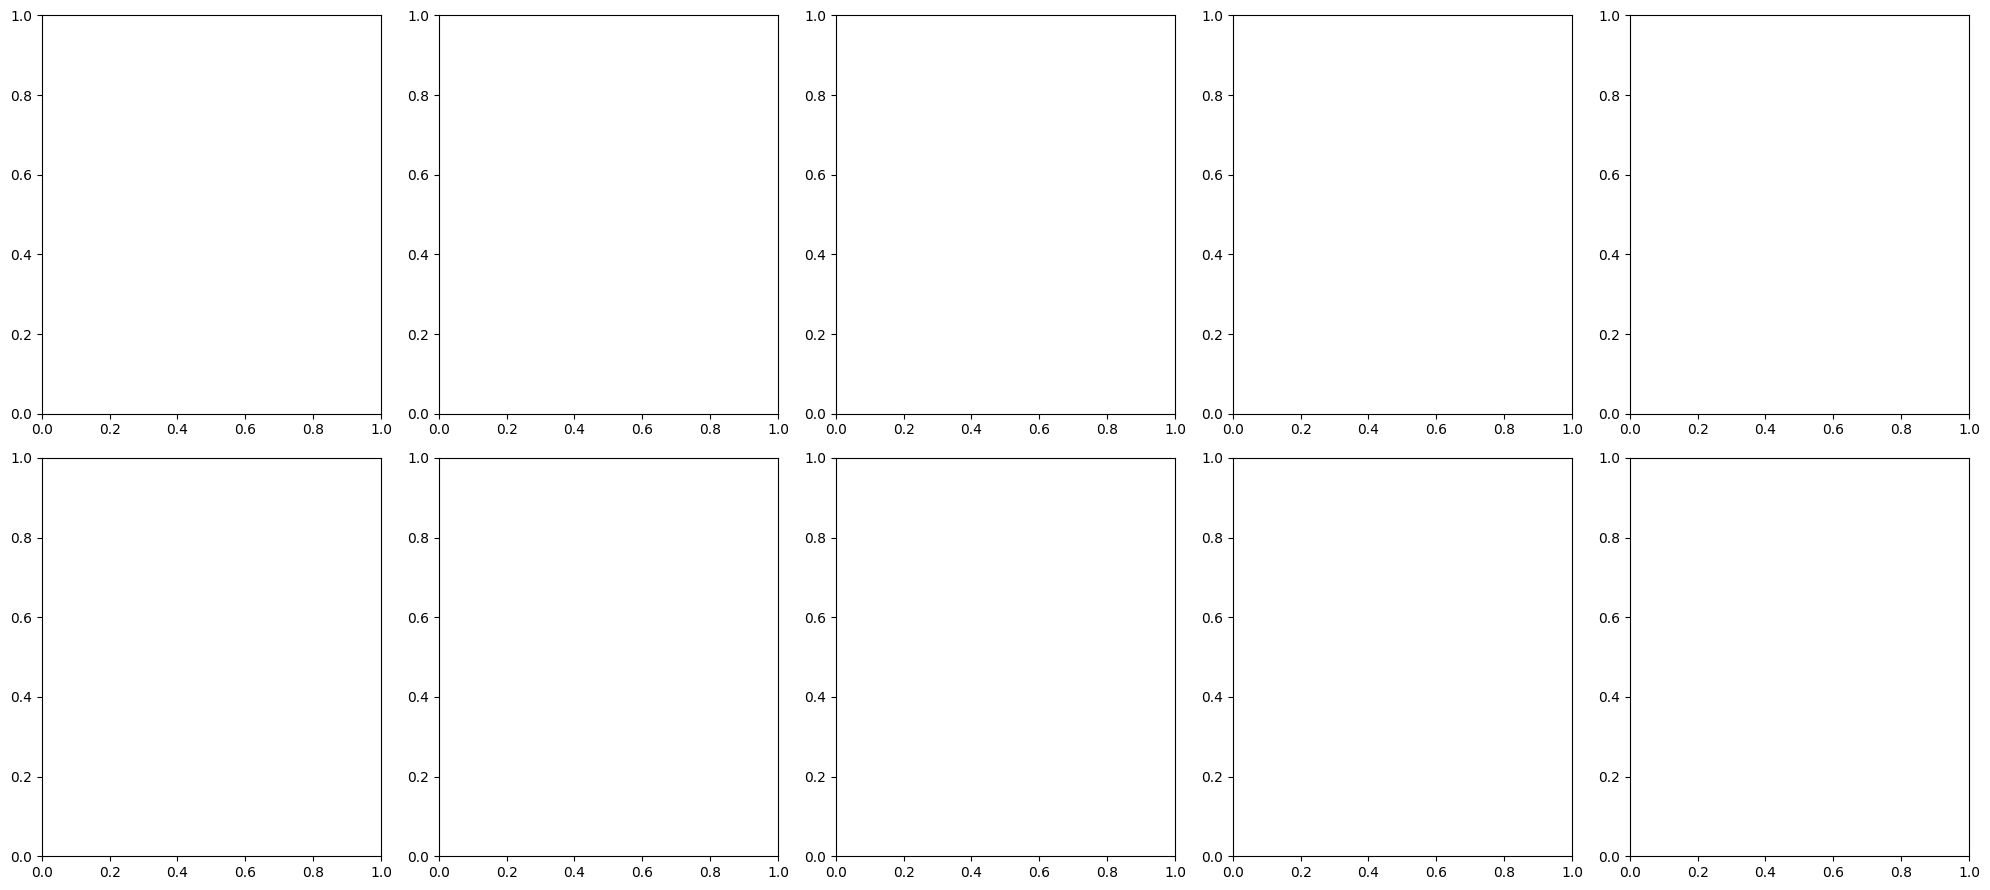

In [9]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9), legend_dist=1.075)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,5), Labels=Labels)

fig_strats = ['Oracle']
fig_labels = ['Oracle']
plot_average_pick_choices(all_pick_choices, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(12, 5))

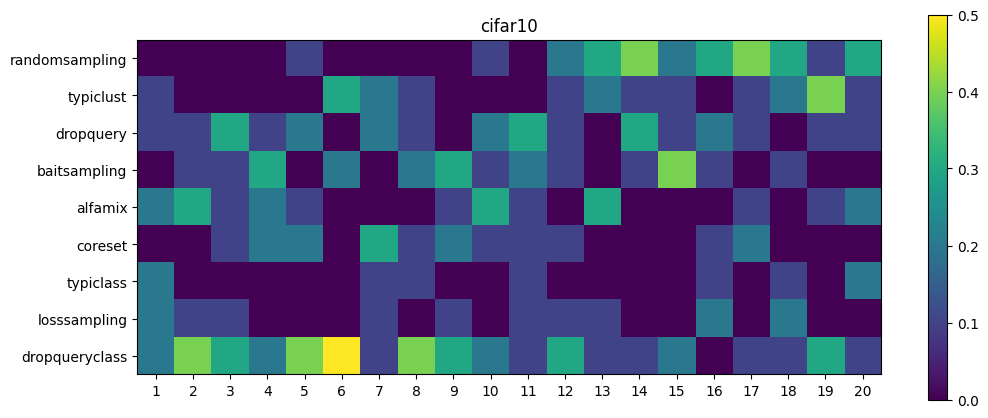

In [10]:
def plot_pick_choices(all_pick_choices, strat, dset, sampling_strategies, figsize=(14, 5), cmap='viridis', title=None):
    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title)
    
    n_queries = 20
    
    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in all_pick_choices[dset][strat]:
            im = []
            for i in range(1, n_queries+1):
                if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                else:
                    im.append(0)
            img.append(im)
        image.append(img)
    image = np.array(image)
    img = np.mean(image, axis=1)

    c1 = plt.imshow(img, cmap=cmap)

    plt.xticks(ticks=range(20), labels=range(1,21), rotation=0)
    plt.yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

    plt.title(dset)
    plt.colorbar(c1)
    plt.show()
    
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'typiclass', 'losssampling', 'dropqueryclass']
plot_pick_choices(all_pick_choices, 'Oracle', 'cifar10', sampling_strategies, figsize=(12, 5))

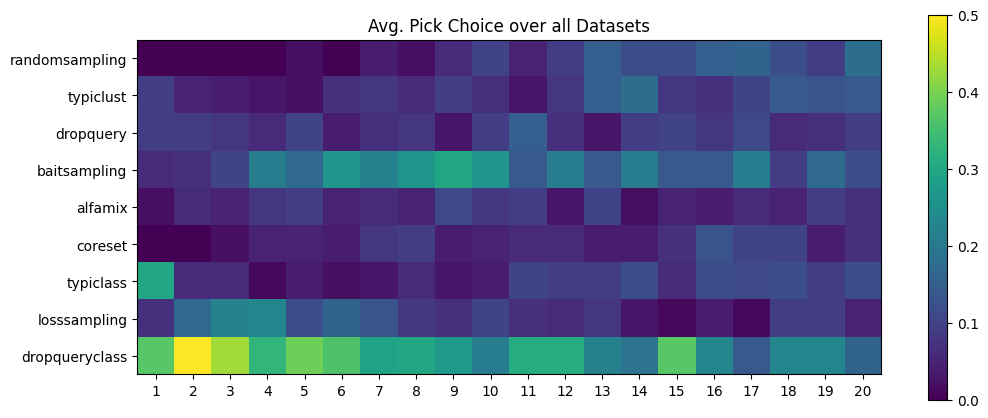

In [ ]:
def plot_avg_pick_choices_dset(all_pick_choices, strat, dsets, sampling_strategies, figsize=(14, 5), cmap='viridis', title=None):
    fig = plt.figure(figsize=figsize)
    if title:
        fig.suptitle(title)
    
    n_queries = 20
    images = []
    for dset in dsets:
        image = []
        for sampl_strat in sampling_strategies:
            img = []
            for seed in all_pick_choices[dset][strat]:
                im = []
                for i in range(1, n_queries+1):
                    if sampl_strat in all_pick_choices[dset][strat][seed] and len(all_pick_choices[dset][strat][seed][sampl_strat])>0:
                        if i == 0:
                            im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                        else:
                            im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                    else:
                        im.append(0)
                img.append(im)
            image.append(img)
        images.append(image)
    images = np.array(images)
    img = np.mean(np.mean(images, axis=0), axis=1)

    c1 = plt.imshow(img, cmap=cmap)

    plt.xticks(ticks=range(20), labels=range(1,21), rotation=0)
    plt.yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)

    plt.title('Avg. Pick Choice over all Datasets')
    plt.colorbar(c1)
    plt.show()
    
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling', 'alfamix', 'coreset', 'typiclass', 'losssampling', 'dropqueryclass']
plot_avg_pick_choices_dset(all_pick_choices, 'Oracle', datasets, sampling_strategies, figsize=(12, 5))

In [ ]:
for dset in all_acc_curves_strategies:
    for strat in all_acc_curves_strategies[dset]:
        for seed in range(1, 11):
            if str(seed) not in all_acc_curves_strategies[dset][strat].keys():
                print(dset, strat, seed)

## Experiment 7: Baselines+Oracle with a new Backbone (SwinV2) on all Image Datasets
Accidentally, i also saved this final oracle under the same experiment number (experiment_7). I therefore need to make a case differentiation between the backbones for future evaluations for both backbones!!!

In [ ]:
all_acc_curves_strategies_2 = {}
all_pick_choices_2 = {}
query_times_2 = {}

In [ ]:
experiment_name = 'experiment_8'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = run.data.params['al.strategy']
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies_2:
                all_acc_curves_strategies_2[dataset] = {}
            if key not in all_acc_curves_strategies_2[dataset]:
                all_acc_curves_strategies_2[dataset][key] = {}
            all_acc_curves_strategies_2[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times_2:
                query_times_2[dataset] = {}
            if key not in query_times_2[dataset]:
                query_times_2[dataset][key] = {}
            query_times_2[dataset][key][seed] = qts
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
experiment_name = 'experiment_7'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle'
        dataset = run.data.params['dataset_name']
        backbone = run.data.params['backbone']
        if backbone == 'swinv2':
            seed = run.data.params['random_seed']
            accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
            qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

            if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
                # Save Accuracies
                if dataset not in all_acc_curves_strategies_2:
                    all_acc_curves_strategies_2[dataset] = {}
                if key not in all_acc_curves_strategies_2[dataset]:
                    all_acc_curves_strategies_2[dataset][key] = {}
                all_acc_curves_strategies_2[dataset][key][seed] = accs

                # Save Query Times
                if dataset not in query_times_2:
                    query_times_2[dataset] = {}
                if key not in query_times_2[dataset]:
                    query_times_2[dataset][key] = {}
                query_times_2[dataset][key][seed] = qts

                # Save Pick Choices 
                if dataset not in all_pick_choices_2:
                    all_pick_choices_2[dataset] = {}
                if key not in all_pick_choices_2[dataset]:
                    all_pick_choices_2[dataset][key] = {}
                all_pick_choices_2[dataset][key][seed] = pick_choices
            else:
                print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

In [ ]:
strategies = ['random', 'margin', 'alfamix', 'badge', 'bait', 'dropquery', 'coreset', 'typiclust', 'Oracle']
Labels = [query_strategies[strat]['n'] for strat in strategies]
dsets = datasets

res_dic = plot_learning_curves(all_acc_curves_strategies_2, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=2, ncols=5, figsize=(20, 9), legend_dist=1.075)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == "random"], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies_2, dsets, strategies, figsize=(6,5), Labels=Labels)

fig_strats = ['Oracle']
fig_labels = ['Oracle']
plot_average_pick_choices(all_pick_choices_2, fig_strats, dsets, sampling_strategies, fig_labels, figsize=(12, 5))

In [ ]:
for dset in all_acc_curves_strategies_2:
    for strat in all_acc_curves_strategies_2[dset]:
        for seed in range(1, 11):
            if str(seed) not in all_acc_curves_strategies_2[dset][strat].keys():
                print(dset, strat, seed)

# Additional Ablations

## Sequential Selection Strategy Reduction

These experiments aim to investigate how our model behaves if we sequentially reduce its pick choices by the least picked Choice

In [3]:
for experiment_name, key in zip(['experiment_11_0']+[f'experiment_12_{i}' for i in range(1, 11)], [f'Oracle (-{i})' for i in range(12)]):
    print('#####################################', experiment_name, '#####################################')
    experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
    runs_strategies = client.search_runs(experiment_ids=experiment_id)
    print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

    for run in runs_strategies:
        if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
            dataset = run.data.params['dataset_name']
            seed = run.data.params['random_seed']
            accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
            qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
            pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

            if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
                # Save Accuracies
                if dataset not in all_acc_curves_strategies:
                    all_acc_curves_strategies[dataset] = {}
                if key not in all_acc_curves_strategies[dataset]:
                    all_acc_curves_strategies[dataset][key] = {}
                all_acc_curves_strategies[dataset][key][seed] = accs

                # Save Query Times
                if dataset not in query_times:
                    query_times[dataset] = {}
                if key not in query_times[dataset]:
                    query_times[dataset][key] = {}
                query_times[dataset][key][seed] = qts

                # Save Pick Choices 
                if dataset not in all_pick_choices:
                    all_pick_choices[dataset] = {}
                if key not in all_pick_choices[dataset]:
                    all_pick_choices[dataset][key] = {}
                all_pick_choices[dataset][key][seed] = pick_choices
            else:
                print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_11_0 #####################################
Found 30 experiments for experiment_11_0 with expected 20 experiments.
##################################### experiment_12_1 #####################################
Found 30 experiments for experiment_12_1 with expected 20 experiments.
##################################### experiment_12_2 #####################################
Found 30 experiments for experiment_12_2 with expected 20 experiments.
##################################### experiment_12_3 #####################################
Found 30 experiments for experiment_12_3 with expected 20 experiments.
##################################### experiment_12_4 #####################################
Found 30 experiments for experiment_12_4 with expected 20 experiments.
##################################### experiment_12_5 #####################################
Found 30 experiments for experiment_12_5 with expected 20 experiments.
######################

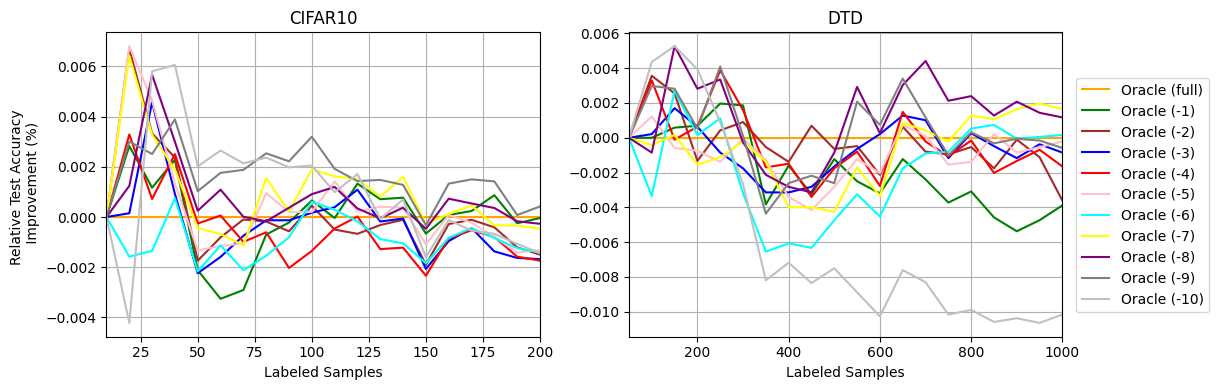

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
Oracle (-0),95.33+/-0.18,78.38+/-0.26
Oracle (-1),0.04+/-0.14,-0.46+/-0.3
Oracle (-2),-0.06+/-0.13,-0.32+/-0.29
Oracle (-3),-0.14+/-0.24,-0.1+/-0.3
Oracle (-4),-0.08+/-0.13,-0.24+/-0.47
Oracle (-5),-0.07+/-0.16,-0.16+/-0.36
Oracle (-6),-0.11+/-0.22,0.07+/-0.33
Oracle (-7),0.05+/-0.16,-0.01+/-0.47
Oracle (-8),0.01+/-0.18,0.14+/-0.52
Oracle (-9),0.17+/-0.16,-0.22+/-0.43


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
Oracle (-0),0.907+/-0.003,0.719+/-0.003
Oracle (-1),0.0+/-0.003,-0.002+/-0.002
Oracle (-2),0.0+/-0.004,-0.0+/-0.003
Oracle (-3),-0.0+/-0.004,-0.001+/-0.003
Oracle (-4),-0.0+/-0.003,-0.001+/-0.005
Oracle (-5),0.0+/-0.004,-0.001+/-0.005
Oracle (-6),-0.001+/-0.005,-0.002+/-0.003
Oracle (-7),0.001+/-0.004,-0.001+/-0.002
Oracle (-8),0.001+/-0.005,0.001+/-0.005
Oracle (-9),0.002+/-0.005,0.0+/-0.002


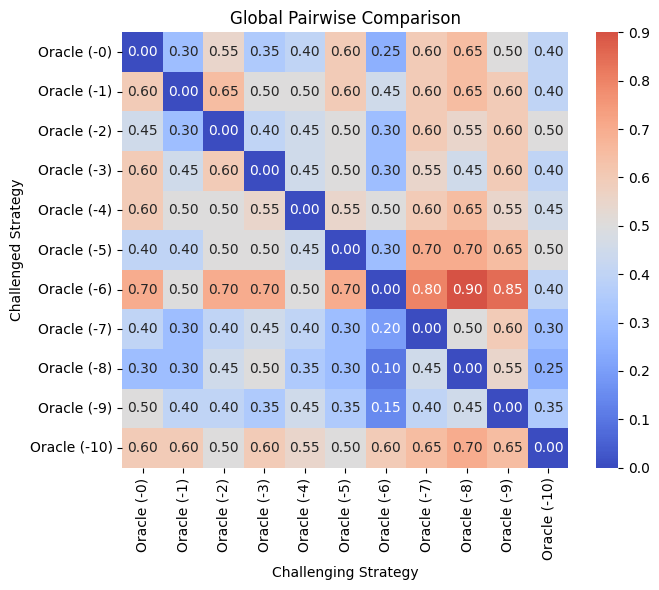

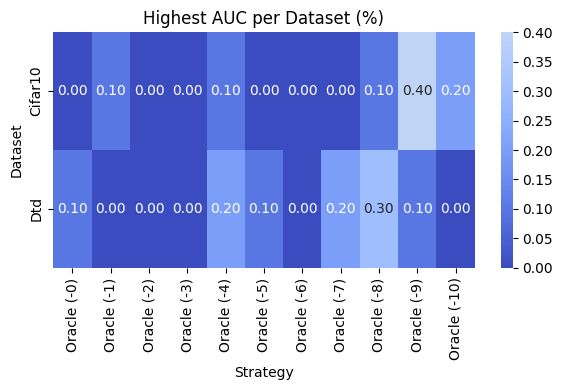

IndexError: list index out of range

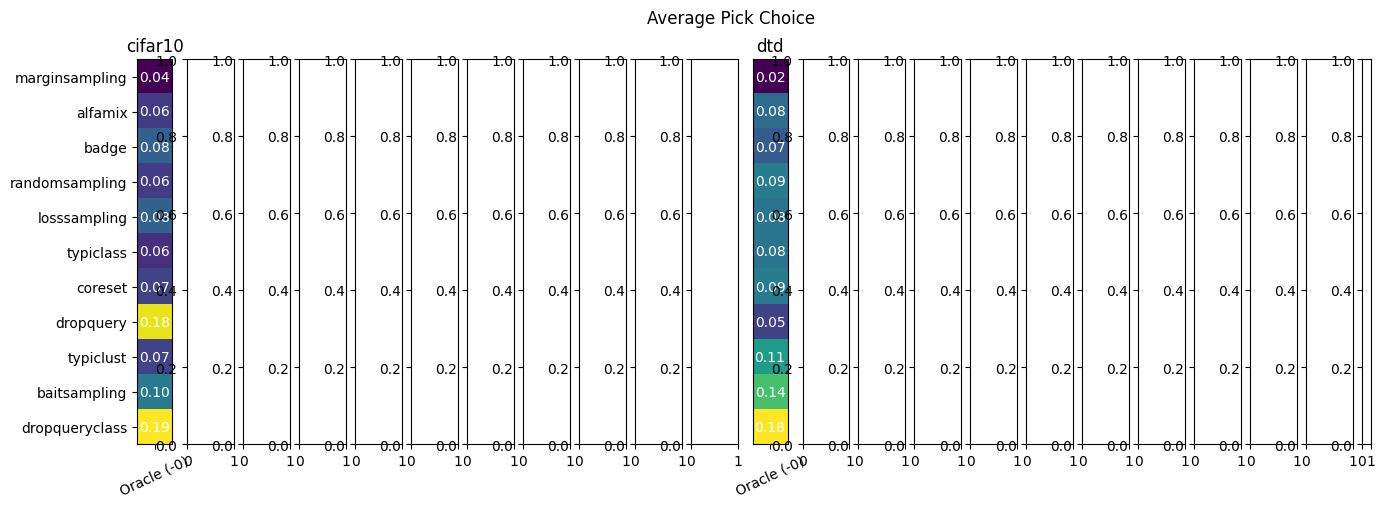

In [11]:
strategies = ['Oracle (-0)', 'Oracle (-1)', 'Oracle (-2)', 'Oracle (-3)', 'Oracle (-4)', 'Oracle (-5)', 'Oracle (-6)', 'Oracle (-7)', 'Oracle (-8)', 'Oracle (-9)', 'Oracle (-10)']
Labels = ['Oracle (-0)', 'Oracle (-1)', 'Oracle (-2)', 'Oracle (-3)', 'Oracle (-4)', 'Oracle (-5)', 'Oracle (-6)', 'Oracle (-7)', 'Oracle (-8)', 'Oracle (-9)', 'Oracle (-10)']
dsets = ['cifar10', 'dtd']
sampling_strategies = ["marginsampling", "alfamix", "badge", "randomsampling", "losssampling", "typiclass", 'coreset', 'dropquery', 'typiclust', 'baitsampling',  'dropqueryclass']
baseline = 'Oracle (-0)'

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(11, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)
plot_average_pick_choices(all_pick_choices=all_pick_choices, fig_strats=strategies, fig_dsets=dsets, sampling_strategies=sampling_strategies, figsize=(16, 5))

## Incrementally raising Number of Batches

One theory is that the oracle overfits on the early cycles and prevents itself from obtaining the best performance later on in the experiment. Therefore, i tested a setting where i incrementally increased its number of batches from 11 in the first cycle to 220 in the final cycle (+11 per cycle) so that in total its the same number of batches.

In [3]:
experiment_name = 'experiment_13'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10)) # n_dsets * n_seeds

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        key = 'Oracle (-2) Inc'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_13 #####################################
Found 20 experiments for experiment_13 with expected 20 experiments.


In [4]:
strategies = ['Oracle (-0)', 'Oracle (-2)', 'Oracle (-2) Inc']
Labels = ['Oracle (-0)', 'Oracle (-2)', 'Oracle (-2) Inc']
dsets = ['cifar10', 'dtd']
baseline = 'Oracle (-0)'

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(8, 4), baseline=baseline, legend_dist=1.11)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)

NameError: name 'plot_learning_curves' is not defined

## Changing the distribution of Number of Batches and Retraining Epochs

In [6]:
experiment_name = 'experiment_14'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 4)) # n_dsets * n_seeds * n_settings

for run in runs_strategies:
    if 'al.strategy' in run.data.params: # This sorts out weird empty runs in the db file
        n_bat = run.data.params['al.optimal.num_batches']
        n_ret = run.data.params['al.optimal.num_retraining_epochs']
        key = f'Oracle ({n_ret}/{n_bat})'
        dataset = run.data.params['dataset_name']
        seed = run.data.params['random_seed']
        accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
        qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
        pick_choices = {k : client.get_metric_history(run.info.run_id, f'bought_{k}') for k in sampling_strategies}

        if str(len(accs)-1) == run.data.params['al.num_acq']: # Sorts out runs that accidentally did not track all cycles
            # Save Accuracies
            if dataset not in all_acc_curves_strategies:
                all_acc_curves_strategies[dataset] = {}
            if key not in all_acc_curves_strategies[dataset]:
                all_acc_curves_strategies[dataset][key] = {}
            all_acc_curves_strategies[dataset][key][seed] = accs

            # Save Query Times
            if dataset not in query_times:
                query_times[dataset] = {}
            if key not in query_times[dataset]:
                query_times[dataset][key] = {}
            query_times[dataset][key][seed] = qts

            # Save Pick Choices 
            if dataset not in all_pick_choices:
                all_pick_choices[dataset] = {}
            if key not in all_pick_choices[dataset]:
                all_pick_choices[dataset][key] = {}
            all_pick_choices[dataset][key][seed] = pick_choices
        else:
            print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_14 #####################################
Found 80 experiments for experiment_14 with expected 80 experiments.


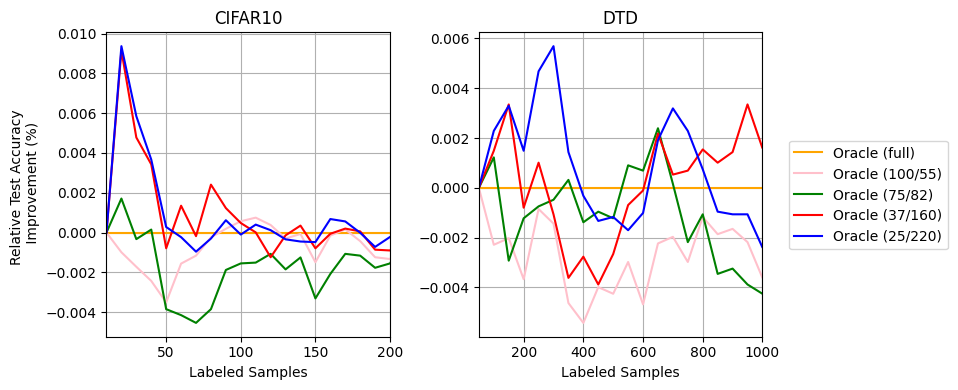

##################################### Final Test-Accuracies (Relative to Random) #####################################


,cifar10,dtd
Oracle (-0),95.33+/-0.18,78.38+/-0.26
Oracle (100/55),-0.02+/-0.11,-0.34+/-0.45
Oracle (75/82),-0.03+/-0.11,-0.38+/-0.43
Oracle (37/160),-0.02+/-0.21,0.2+/-0.31
Oracle (25/220),0.02+/-0.2,-0.29+/-0.5


##################################### Test-AUCs (Relative to Random) #####################################


,cifar10,dtd
Oracle (-0),0.907+/-0.003,0.719+/-0.003
Oracle (100/55),-0.001+/-0.003,-0.003+/-0.004
Oracle (75/82),-0.002+/-0.004,-0.001+/-0.004
Oracle (37/160),0.001+/-0.004,0.0+/-0.003
Oracle (25/220),0.001+/-0.003,0.001+/-0.004


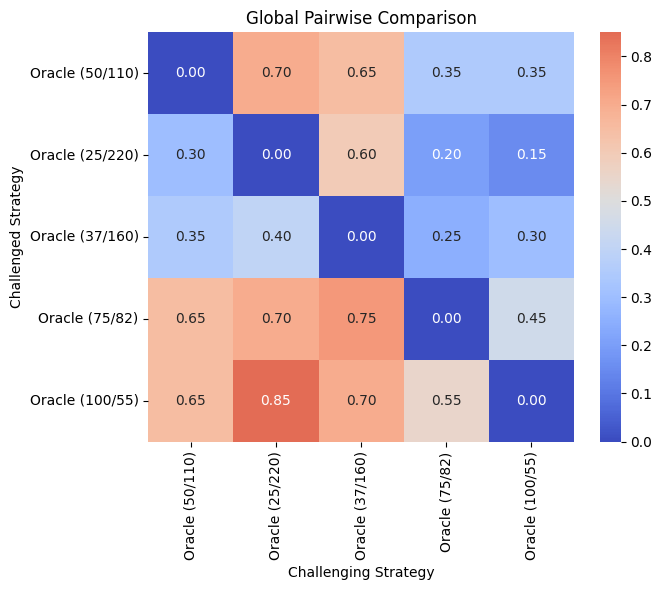

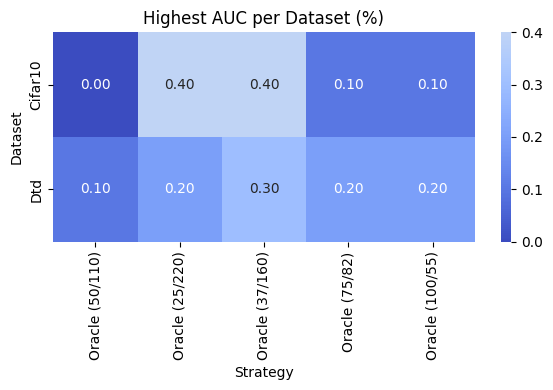

In [7]:
strategies = ['Oracle (-0)', 'Oracle (25/220)', 'Oracle (37/160)', 'Oracle (75/82)', 'Oracle (100/55)']
Labels = ['Oracle (50/110)', 'Oracle (25/220)', 'Oracle (37/160)', 'Oracle (75/82)', 'Oracle (100/55)']
dsets = ['cifar10', 'dtd']
baseline = 'Oracle (-0)'

res_dic = plot_learning_curves(all_acc_curves_strategies, strats=strategies, dsets=dsets, datasets=datasets, query_strategies=query_strategies, nrows=1, ncols=2, figsize=(8, 4), baseline=baseline, legend_dist=1.2)
final_acc_rel, auc_values_rel, final_acc_abs, auc_values_abs = res_dic['acc_rel'], res_dic['auc_rel'], res_dic['acc_abs'], res_dic['auc_abs']

print('##################################### Final Test-Accuracies (Relative to Random) #####################################')
df = pd.DataFrame(final_acc_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s = df.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s)

print('##################################### Test-AUCs (Relative to Random) #####################################')
df2 = pd.DataFrame(auc_values_rel)
random_row = pd.IndexSlice[df.index[df.index == baseline], :]
s2 = df2.style.map(style_negative, props='color:red;').map(df_style, subset=random_row)
display(s2)

plot_global_pairwise_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(7,6), Labels=Labels)
plot_global_comparison(all_acc_curves_strategies, dsets, strategies, figsize=(6,4), Labels=Labels)